In [21]:
#Step 1: Import libraries and fetch data
import pandas as pd
import yfinance as yf

In [22]:
# Step 2: Select tickers and fetch historical data, focusing on the 'Close' prices, and calculating the return prices
tickers = ["AAPL", "GOOGL", "MSFT", "AMZN", "NVDA"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")
close_prices = data['Close']
print(close_prices)

ret = round((close_prices.iloc[-1] - close_prices.iloc[0]) / close_prices.iloc[0] * 100, 2)
print(ret)


[*********************100%***********************]  5 of 5 completed

Ticker            AAPL        AMZN       GOOGL        MSFT        NVDA
Date                                                                  
2024-01-02  183.562180  149.929993  137.037384  363.801483   48.138569
2024-01-03  182.187729  148.470001  137.781265  363.536652   47.539936
2024-01-04  179.873962  144.570007  135.271988  360.927399   47.968678
2024-01-05  179.152100  145.240005  134.617371  360.740967   49.067001
2024-01-08  183.483078  149.100006  137.701889  367.548706   52.221077
...                ...         ...         ...         ...         ...
2024-12-23  253.649429  225.059998  193.734344  430.147217  139.624252
2024-12-24  256.560791  229.050003  195.207520  434.179321  140.174088
2024-12-26  257.375610  227.050003  194.699875  432.973663  139.884171
2024-12-27  253.967377  223.750000  191.872925  425.482513  136.965118
2024-12-30  250.598892  221.300003  190.359955  419.849365  137.444962

[251 rows x 5 columns]
Ticker
AAPL      36.52
AMZN      47.60
GOOGL     38.9

In [23]:
#Step 3: Sort returns from highest to lowest
returns = ret.sort_values(ascending=False)
print(returns)

Ticker
NVDA     185.52
AMZN      47.60
GOOGL     38.91
AAPL      36.52
MSFT      15.41
dtype: float64


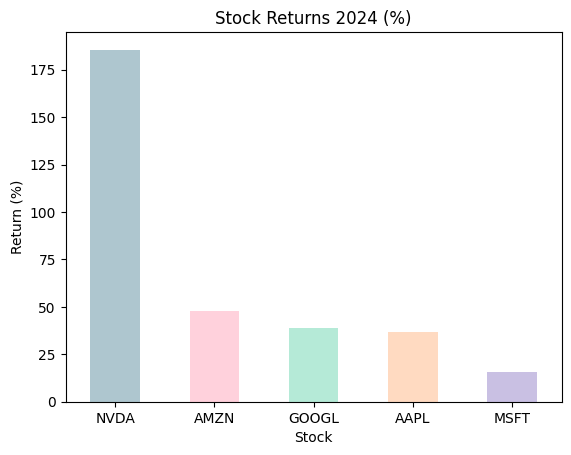

In [24]:
# Step 4: Visualise stock return data using a bar chart with each colour representing a different stock
import matplotlib.pyplot as plt

returns.plot(kind='bar', color=['#AEC6CF', '#FFD1DC', '#B5EAD7', '#FFDAC1', '#C9C0E3'])
plt.title('Stock Returns 2024 (%)')
plt.xlabel('Stock')
plt.ylabel('Return (%)')
plt.xticks(rotation=0)
plt.show()

In [25]:
daily_returns = close_prices.pct_change()

vol = daily_returns.std()
annual_vol = vol * (252 ** 0.5)

sharpe = (ret / 100) / annual_vol

print(daily_returns)
print(annual_vol)
print(sharpe)

Ticker          AAPL      AMZN     GOOGL      MSFT      NVDA
Date                                                        
2024-01-02       NaN       NaN       NaN       NaN       NaN
2024-01-03 -0.007488 -0.009738  0.005428 -0.000728 -0.012436
2024-01-04 -0.012700 -0.026268 -0.018212 -0.007177  0.009019
2024-01-05 -0.004013  0.004634 -0.004839 -0.000517  0.022897
2024-01-08  0.024175  0.026577  0.022913  0.018872  0.064281
...              ...       ...       ...       ...       ...
2024-12-23  0.003065  0.000622  0.016823 -0.003092  0.036897
2024-12-24  0.011478  0.017729  0.007604  0.009374  0.003938
2024-12-26  0.003176 -0.008732 -0.002601 -0.002777 -0.002068
2024-12-27 -0.013242 -0.014534 -0.014520 -0.017302 -0.020868
2024-12-30 -0.013263 -0.010950 -0.007885 -0.013239  0.003503

[251 rows x 5 columns]
Ticker
AAPL     0.224488
AMZN     0.281452
GOOGL    0.281099
MSFT     0.199714
NVDA     0.525406
dtype: float64
Ticker
AAPL     1.626812
AMZN     1.691232
GOOGL    1.384212
MSFT     0

In [26]:
summary = pd.DataFrame({
    'Return (%)': ret,
    'Annual Volatility': annual_vol,
    'Sharpe Ratio': sharpe
})

print(summary.sort_values('Sharpe Ratio', ascending=False))

        Return (%)  Annual Volatility  Sharpe Ratio
Ticker                                             
NVDA        185.52           0.525406      3.530982
AMZN         47.60           0.281452      1.691232
AAPL         36.52           0.224488      1.626812
GOOGL        38.91           0.281099      1.384212
MSFT         15.41           0.199714      0.771605


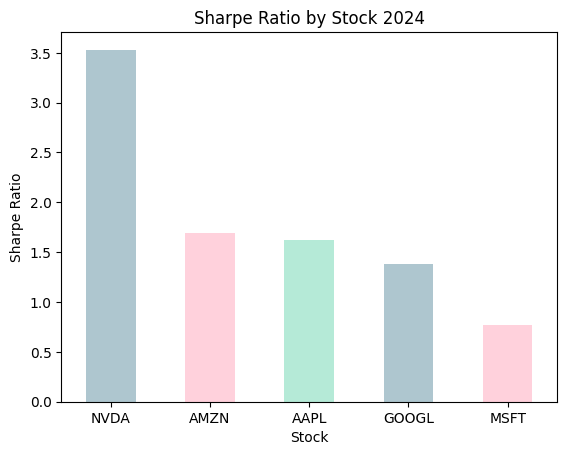

In [27]:
import matplotlib.pyplot as plt

summary.sort_values('Sharpe Ratio', ascending=False)['Sharpe Ratio'].plot(kind='bar', color=['#AEC6CF', '#FFD1DC', '#B5EAD7'])
plt.title('Sharpe Ratio by Stock 2024')
plt.xlabel('Stock')
plt.ylabel('Sharpe Ratio')
plt.xticks(rotation=0)
plt.show()